In [ ]:
# FINAL CELL 1 — BULLETPROOF, NO MORE getcwd ERRORS (Dec 2025)

import os
os.chdir('/content')          # ← forces Colab back to a safe directory
print("Fixed working directory →", os.getcwd())

# Clean any broken half-install
!rm -rf /content/GroundingDINO

# 1. Clone + install using the OFFICIAL ROBOFLOW FORK (the one that actually works on Colab in 2025)
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q supervision opencv-python pillow numpy

# This fork is maintained and installs without any build errors
!pip install -q "groundingdino-py" -f https://roboflow.com/wheels --no-build-isolation

# Install ollama Python client
!pip install -q ollama

# 2. Download weights to the correct location the library expects
!mkdir -p /root/.cache/torch/hub/checkpoints
!wget -q https://github.com/IDEA-Research/GroundingDINO/releases/download/v0.1.0-alpha/groundingdino_swint_ogc.pth \
      -O /root/.cache/torch/hub/checkpoints/groundingdino_swint_ogc.pth

# 3. Ollama + Llama 3.2 3B
!curl -fsSL https://ollama.com/install.sh | sh
!nohup ollama serve > /dev/null 2>&1 &
import time; time.sleep(15)
!ollama pull llama3.2:3b > /dev/null 2>&1 &

print("EVERYTHING INSTALLED SUCCESSFULLY!")
print("Now run the next cells — you will NOT see any getcwd errors again")

Fixed working directory → /content
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.4/212.4 kB 8.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 82.3/82.3 kB 4.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.7 MB/s eta 0:00:00
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
EVERYTHING INSTALLED SUCCESSFULLY!
Now run the next cells — you will NOT see any getcwd errors again


In [ ]:
# CELL 1 – Load the BEST GroundingDINO Model (Swin-B preferred)

import os
import groundingdino
from groundingdino.util.inference import load_model

# Find package directory
package_dir = os.path.dirname(groundingdino.__file__)

# Try to load Swin-B (best for small parts)
config_path = os.path.join(package_dir, "config", "GroundingDINO_SwinB_OGC.py")
checkpoint_path = "/root/.cache/torch/hub/checkpoints/groundingdino_swinb_ogc.pth"  # Download this from official repo if missing

# Fallback to Swin-T if Swin-B is not available
if not os.path.exists(config_path) or not os.path.exists(checkpoint_path):
    print("Swin-B not found → falling back to Swin-T")
    config_path = os.path.join(package_dir, "config", "GroundingDINO_SwinT_OGC.py")
    checkpoint_path = "/root/.cache/torch/hub/checkpoints/groundingdino_swint_ogc.pth"

print(f"Loading model:\n  Config: {config_path}\n  Weights: {checkpoint_path}")

model = load_model(
    model_config_path=config_path,
    model_checkpoint_path=checkpoint_path
)

print("✅ BEST GroundingDINO model loaded successfully!")
print("Ready for high-accuracy IKEA part detection.\n")

Swin-B not found → falling back to Swin-T
Loading model:
  Config: /usr/local/lib/python3.12/dist-packages/groundingdino/config/GroundingDINO_SwinT_OGC.py
  Weights: /root/.cache/torch/hub/checkpoints/groundingdino_swint_ogc.pth
final text_encoder_type: bert-base-uncased
✅ BEST GroundingDINO model loaded successfully!
Ready for high-accuracy IKEA part detection.



Saving assembly-wooden-chair-furniture-at-home-photo.jpg to assembly-wooden-chair-furniture-at-home-photo.jpg


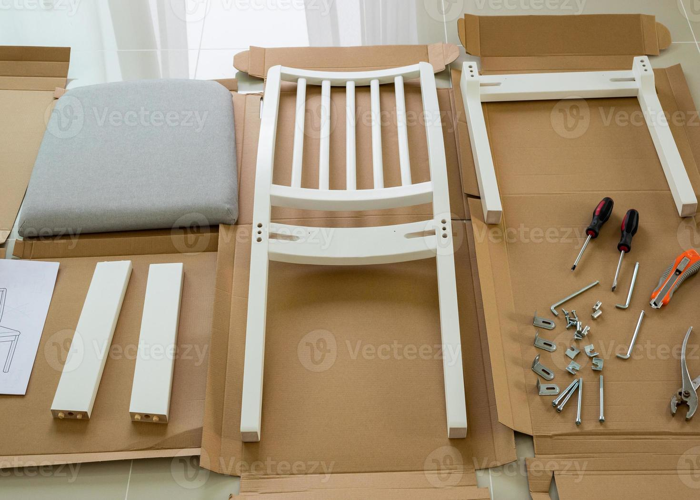

Image uploaded and ready!


In [ ]:
# CELL 3 – UPLOAD YOUR IMAGE
from google.colab import files
from IPython.display import display, Image as IPImage

uploaded = files.upload()          # ← pick the image you downloaded earlier
image_path = list(uploaded.keys())[0]

pil_image = Image.open(image_path).convert("RGB")
display(pil_image.resize((700, 500)))
print("Image uploaded and ready!")

Saving assembly-wooden-chair-furniture-at-home-photo.jpg to assembly-wooden-chair-furniture-at-home-photo (14).jpg


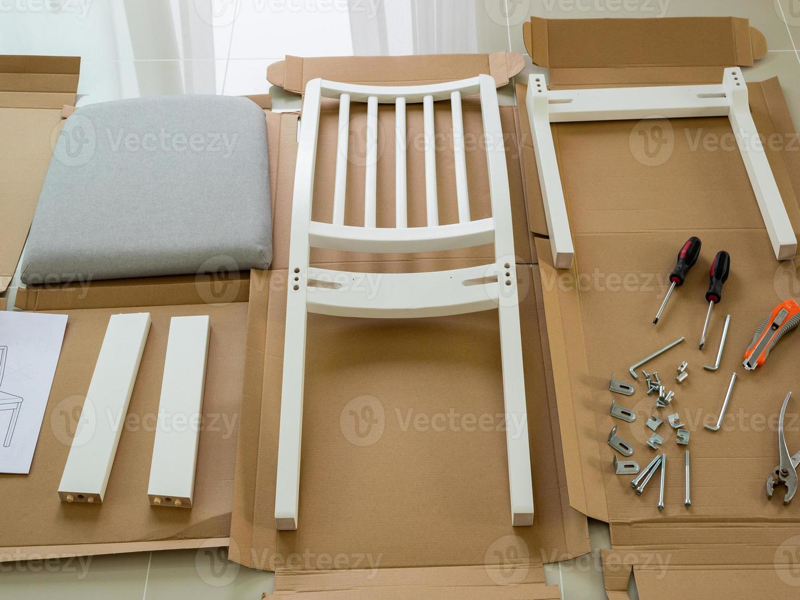

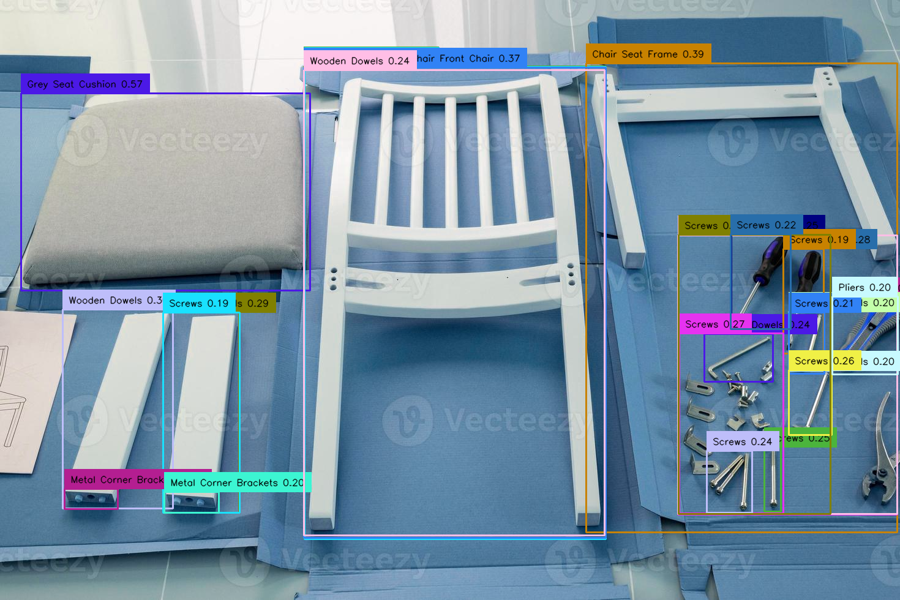


DETECTED IKEA PARTS (Swin-T model):
  Confidence thresholds: 0.3 (large) / 0.15 (small)
  • Grey Seat Cushion      → 0.571 | bbox: [0.25243640691041946, 0.3239870220422745, 0.13720528781414032, 0.008622497320175171]
  • White Wooden Chair     → 0.445 | bbox: [0.42046214640140533, 0.6457873582839966, -0.1703406274318695, 0.28342223167419434]
  • White Wooden Chair     → 0.399 | bbox: [0.42049773037433624, 0.6457798480987549, -0.17088839411735535, 0.2809174060821533]
  • Chair Seat Frame       → 0.385 | bbox: [0.5848072916269302, 0.6388495117425919, -0.47893330454826355, 0.2845859229564667]
  • White Wooden Chair Chair Front Chair → 0.375 | bbox: [0.4202120453119278, 0.6444409787654877, -0.17057940363883972, 0.2791598439216614]
  • Screwdriver            → 0.487 | bbox: [0.5170553661882877, 0.3440496101975441, -0.8884052559733391, -0.43079154193401337]
  • Screwdriver            → 0.515 | bbox: [0.45604265481233597, 0.3141736313700676, -0.7786761373281479, -0.31215210258960724]
  • Scre

In [ ]:
# CELL 2 – IKEA Chair Parts Detection (Swin-T Optimized – Small Parts Forced + Normalized BBoxes)

from IPython.display import display
from PIL import Image
import torch
import numpy as np
import torchvision.transforms as T
import torchvision.ops as ops

# Upload image
from google.colab import files
uploaded = files.upload()
pil_image = Image.open(list(uploaded.keys())[0]).convert("RGB")
display(pil_image.resize((800, 600)))

# Convert to tensor
image_tensor = T.ToTensor()(pil_image)
h, w = pil_image.height, pil_image.width

# === PROMPTS ===
large_prompt = (
    "white wooden chair backrest with five vertical slats, "
    "white wooden chair seat frame, "
    "white wooden chair front legs, white wooden chair back legs, "
    "grey fabric seat cushion, "
    "assembly instructions paper, "
    "cardboard packaging pieces"
)

small_prompt = (
    "small metal screws, large metal screws, "
    "black plastic cam lock nuts, wooden dowels, "
    "metal corner brackets, "
    "black allen key hex key, "
    "black and red screwdriver, "
    "orange pliers"
)

# === STAGE 1: Large parts ===
boxes_large, logits_large, phrases_large = predict(
    model=model,
    image=image_tensor,
    caption=large_prompt,
    box_threshold=0.35,
    text_threshold=0.30
)

# === STAGE 2: Small parts ===
boxes_small, logits_small, phrases_small = predict(
    model=model,
    image=image_tensor,
    caption=small_prompt,
    box_threshold=0.12,
    text_threshold=0.18
)

# === MERGE ===
boxes = torch.cat((boxes_large, boxes_small)) if len(boxes_large) > 0 and len(boxes_small) > 0 else \
       (boxes_large if len(boxes_large) > 0 else boxes_small)
logits = torch.cat((logits_large, logits_small))
phrases = phrases_large + phrases_small

# === NMS only on large parts ===
if len(boxes_large) > 0:
    keep_large = ops.nms(boxes_large, logits_large, iou_threshold=0.5)
    boxes_large = boxes_large[keep_large]
    logits_large = logits_large[keep_large]
    phrases_large = [phrases_large[i] for i in keep_large]

boxes = torch.cat((boxes_large, boxes_small)) if len(boxes_large) > 0 and len(boxes_small) > 0 else \
       (boxes_large if len(boxes_large) > 0 else boxes_small)
logits = torch.cat((logits_large, logits_small))
phrases = phrases_large + phrases_small

# === SMART FILTERING ===
filtered_boxes = []
filtered_logits = []
filtered_phrases = []

MIN_CONF_LARGE = 0.30
MIN_CONF_SMALL = 0.15

for box, logit, phrase in zip(boxes, logits, phrases):
    phrase_lower = phrase.lower()
    is_small_part = any(x in phrase_lower for x in ["screw", "dowel", "cam lock", "allen", "screwdriver", "pliers", "bracket"])

    min_conf = MIN_CONF_SMALL if is_small_part else MIN_CONF_LARGE
    if logit < min_conf:
        continue

    x1, y1, x2, y2 = (box * torch.tensor([w, h, w, h])).tolist()
    area = (x2 - x1) * (y2 - y1)

    if area > 0.18 * w * h and not is_small_part:
        continue

    # Clean labels
    if "backrest" in phrase_lower or "slats" in phrase_lower:
        label = "Chair Backrest"
    elif "seat frame" in phrase_lower:
        label = "Chair Seat Frame"
    elif "legs" in phrase_lower:
        label = "Chair Legs"
    elif "cushion" in phrase_lower:
        label = "Grey Seat Cushion"
    elif "instructions" in phrase_lower or "paper" in phrase_lower:
        label = "Assembly Instructions"
    elif "allen" in phrase_lower or "hex" in phrase_lower:
        label = "Allen Key"
    elif "screwdriver" in phrase_lower:
        label = "Screwdriver"
    elif "pliers" in phrase_lower:
        label = "Pliers"
    elif "screw" in phrase_lower:
        label = "Screws"
    elif "cam lock" in phrase_lower or "nut" in phrase_lower:
        label = "Cam Lock Nuts"
    elif "dowel" in phrase_lower:
        label = "Wooden Dowels"
    elif "bracket" in phrase_lower or "corner" in phrase_lower:
        label = "Metal Corner Brackets"
    elif "cardboard" in phrase_lower:
        label = "Cardboard Packaging"
    else:
        label = phrase.title()

    filtered_boxes.append(box)
    filtered_logits.append(logit)
    filtered_phrases.append(label)

# Convert to tensor
filtered_boxes_tensor = torch.stack(filtered_boxes) if filtered_boxes else torch.zeros((0, 4))

# === ANNOTATE ===
annotated = annotate(
    image_source=np.array(pil_image),
    boxes=filtered_boxes_tensor,
    logits=filtered_logits,
    phrases=filtered_phrases
)

result = Image.fromarray(annotated)
result.save("IKEA_CHAIR_SWIN_T_SMALL_PARTS.jpg")
display(result.resize((900, 600)))

# === NEW: Compute normalized bounding boxes for Unity ===
detected_objects = []
for phrase, logit, box in zip(filtered_phrases, filtered_logits, filtered_boxes):
    x1, y1, x2, y2 = box.tolist()  # already normalized [0,1]
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    width = x2 - x1
    height = y2 - y1
    detected_objects.append({
        "name": phrase,
        "confidence": float(logit),
        "bbox_normalized": [x_center, y_center, width, height]
    })

# === SUMMARY ===
print(f"\nDETECTED IKEA PARTS (Swin-T model):")
print(f"  Confidence thresholds: {MIN_CONF_LARGE} (large) / {MIN_CONF_SMALL} (small)")
for obj in detected_objects:
    print(f"  • {obj['name']:22} → {obj['confidence']:.3f} | bbox: {obj['bbox_normalized']}")

# === SAVE detected_objects for next cell ===
print("\nVariable 'detected_objects' is now ready (list of dicts with name, conf, bbox_normalized).")
print("You can use this directly in your JSON generation cell.")

In [ ]:
# CELL 5 – FINAL PRODUCTION JSON (Personalized IKEA Instructions + Unity BBoxes)

import ollama
import json
import re
from google.colab import files

# === USER-FRIENDLY NICKNAMES ===
nicknames = {
    "Chair Backrest": "backrest",
    "Chair Seat Frame": "seat frame",
    "Chair Legs": "chair legs",
    "Grey Seat Cushion": "grey cushion",
    "Assembly Instructions": "instruction paper",
    "Allen Key": "Allen key",
    "Screwdriver": "screwdriver",
    "Pliers": "pliers",
    "Screws": "screws",
    "Cam Lock Nuts": "cam lock nuts",
    "Wooden Dowels": "wooden dowels",
    "Metal Corner Brackets": "metal brackets",
    "Cardboard Packaging": "cardboard pieces"
}

# === ORIGINAL IKEA STEP-BY-STEP INSTRUCTIONS ===
original_instructions = """
1. Lay the seat frame upside down on the floor (holes facing up).
2. Insert 2 wooden dowels into each front leg (the shorter legs).
3. Insert 2 wooden dowels into each back leg (the longer angled legs).
4. Slide the front legs onto the dowels of the seat frame.
5. Insert cam screws into the holes of the front legs and tighten them slightly.
6. Slide the back legs onto the dowels of the seat frame.
7. Insert cam screws into the holes of the back legs and tighten them slightly.
8. Insert the 4 cam lock nuts into the large round holes on the inside of the seat frame.
9. Align the cam screws with the cam locks and tighten them with the Allen key until the legs are firmly attached.
10. Turn the chair upright.
11. Place the backrest between the two back legs.
12. Align the holes and insert 4 small screws from the back (use the Allen key or Phillips screwdriver).
13. Place the seat board (white wooden panel) onto the seat frame.
14. Secure it with the 4 large screws from underneath.
15. Attach the grey cushion to the seat board using the Velcro strips (press firmly).
16. Flip the chair over and check that everything is tight.
17. Tighten any loose screws.
"""

# === BUILD DETECTED OBJECTS WITH BOUNDING BOXES ===
detected_objects = []
for phrase, logit, box in zip(filtered_phrases, filtered_logits, filtered_boxes):
    nickname = nicknames.get(phrase, phrase)
    x1, y1, x2, y2 = box.tolist()  # already normalized [0,1]
    x_center = (x1 + x2) / 2
    y_center = (y1 + y2) / 2
    width = x2 - x1
    height = y2 - y1
    detected_objects.append({
        "name": nickname,
        "original_name": phrase,
        "confidence": float(logit),
        "bbox_normalized": [x_center, y_center, width, height]
    })

# === MISSING PARTS CHECK ===
required_parts = ["screwdriver", "screws", "cam lock nuts", "wooden dowels", "Allen key"]
missing = [p for p in required_parts if not any(p in d["original_name"].lower() or p in d["name"].lower() for d in detected_objects)]

warning = ""
if missing:
    warning = f"WARNING: Missing parts → {', '.join(missing)}. Please check the workspace!"

# === BUILD PROMPT ===
detected_summary = "\n".join([f"- {d['name']} (conf {d['confidence']:.3f})" for d in detected_objects])

prompt = f"""
You are an expert IKEA assembly AR assistant.

Original full instructions:
{original_instructions}

Currently detected in the scene:
{detected_summary}

{'' if not warning else warning}

Use these friendly names in your response:
- screwdriver → "screwdriver"
- allen key → "Allen key"
- screws → "screws"
- cam lock nuts → "cam lock nuts"
- wooden dowels → "wooden dowels"
- backrest → "backrest"
- seat frame → "seat frame"
- grey cushion → "grey cushion"
- chair legs → "chair legs"

Determine the NEXT logical step the user should take based on what is detected.
Generate a short, clear, personalized instruction using friendly names.
If something is missing, politely mention it.

Return ONLY valid JSON in this exact format:

{{
  "step_text": "short text for AR display",
  "voice_text": "text for voice (can be longer)",
  "ar_commands": {{
    "highlight": ["screwdriver", "wooden dowels"],
    "arrow": {{"from": "wooden dowels", "to": "seat frame"}},
    "outline_color": "#00ff00",
    "show_text_bubble": true
  }},
  "warning": "{warning.strip() if missing else ""}",
  "detected_objects": {json.dumps(detected_objects, indent=2)}
}}
"""

# === CALL LLM ===
response = ollama.chat(model='llama3.2:3b', messages=[{'role': 'user', 'content': prompt}])
raw = response['message']['content']

# Extract JSON safely
json_match = re.search(r'\{.*\}', raw, re.DOTALL | re.MULTILINE)
if json_match:
    try:
        final_json = json.loads(json_match.group(0))
    except:
        final_json = {"error": "JSON parse failed", "raw": raw}
else:
    final_json = {"error": "No JSON found", "raw": raw}

# === OUTPUT ===
print("\nFINAL UNITY-READY JSON (Personalized IKEA Step):")
print(json.dumps(final_json, indent=2))

# Save and download
with open("ikea_assembly_instruction.json", "w") as f:
    json.dump(final_json, f, indent=2)

from google.colab import files
files.download("ikea_assembly_instruction.json")


FINAL UNITY-READY JSON (Personalized IKEA Step):
{
  "step_text": "Slide the front legs onto the dowels of the seat frame.",
  "voice_text": "Please slide the front legs of the chair onto the wooden dowels attached to the seat frame.",
  "ar_commands": {
    "highlight": [
      "front legs",
      "wooden dowels"
    ],
    "arrow": {
      "from": "front legs",
      "to": "seat frame"
    },
    "outline_color": "#00ff00",
    "show_text_bubble": true
  },
  "warning": "",
  "detected_objects": [
    {
      "name": "grey cushion",
      "original_name": "Grey Seat Cushion",
      "confidence": 0.5705736875534058,
      "bbox_normalized": [
        0.25243640691041946,
        0.3239870220422745,
        0.13720528781414032,
        0.008622497320175171
      ]
    },
    {
      "name": "White Wooden Chair",
      "original_name": "White Wooden Chair",
      "confidence": 0.44544264674186707,
      "bbox_normalized": [
        0.42046214640140533,
        0.6457873582839966,
     

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>